# EEGNet Training Pipeline — 64 Channel EDF Dataset
**Architecture: EEGNet | Classes: REST vs TASK | 64ch, 256 samples @ 256Hz**

## Step 1 — Install Dependencies

In [1]:
!pip install mne -q 2>/dev/null
import torch
print(f'torch: {torch.__version__}, CUDA: {torch.cuda.is_available()}')

torch: 2.10.0+cu128, CUDA: True


## Step 2 — Imports & Config

In [2]:
import os, glob, warnings
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import mne
warnings.filterwarnings('ignore')
mne.set_log_level('WARNING')

# ── CONFIGURATION ─────────────────────────────────────────────────
DATA_DIR   = '/kaggle/input/datasets/madhava16/eeg-movement-imagery-database'
SAVE_PATH  = '/kaggle/working/eegnet_best_64ch.pt'

N_CHANNELS = 64
N_TIMES    = 256
SFREQ      = 256.0
CLASSES    = ['REST', 'TASK']

F1         = 16
D          = 2
F2         = F1 * D
KERN_LEN   = 64
DROPOUT    = 0.5

BATCH_SIZE = 64
EPOCHS     = 150
LR         = 1e-4
PATIENCE   = 25
VAL_SPLIT  = 0.2
TEST_SPLIT = 0.1
SEED       = 42

torch.manual_seed(SEED)
np.random.seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print(f'Channels: {N_CHANNELS} | Samples: {N_TIMES} | sfreq: {SFREQ} Hz')

Device: cuda
Channels: 64 | Samples: 256 | sfreq: 256.0 Hz


## Step 3 — EDF Loader & Epoching

In [3]:
def parse_event_file(event_path):
    """Parse .edf.event file with multi-encoding fallback."""
    events = []
    if not os.path.exists(event_path):
        return events
    for encoding in ['utf-8', 'latin-1', 'iso-8859-1', 'cp1252']:
        try:
            with open(event_path, 'r', encoding=encoding) as f:
                for line in f:
                    line = line.strip()
                    if not line or line.startswith('#'):
                        continue
                    parts = line.replace(',', ' ').split()
                    if len(parts) >= 3:
                        try:
                            onset    = float(parts[0])
                            duration = float(parts[1])
                            label    = parts[2].upper()
                            events.append((onset, duration, label))
                        except ValueError:
                            continue
            return events
        except (UnicodeDecodeError, Exception):
            continue
    return events  # fallback: empty → use filename suffix


def load_edf_epochs(edf_path, n_channels=N_CHANNELS, n_times=N_TIMES, sfreq=SFREQ):
    """Load EDF, bandpass filter, epoch, z-score normalize."""
    raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
    raw.pick_types(eeg=True, exclude='bads')

    if raw.info['sfreq'] != sfreq:
        raw.resample(sfreq)

    raw.filter(0.5, 40.0, fir_design='firwin', verbose=False)
    data = raw.get_data()  # (n_ch, n_samples)

    # Pad or trim channels to exactly n_channels
    if data.shape[0] < n_channels:
        pad  = np.zeros((n_channels - data.shape[0], data.shape[1]))
        data = np.vstack([data, pad])
    elif data.shape[0] > n_channels:
        data = data[:n_channels, :]

    event_path = edf_path + '.event'
    events     = parse_event_file(event_path)

    X, y = [], []

    if events:
        for onset, duration, label in events:
            if label not in CLASSES:
                continue
            start = int(onset * sfreq)
            end   = start + n_times
            if end > data.shape[1]:
                continue
            epoch = data[:, start:end]
            # Global clip + normalize
            epoch = epoch - epoch.mean(axis=1, keepdims=True)
            sigma = epoch.std()  + 1e-6
            epoch = np.clip(epoch / sigma, -5, 5)  # clip outliers
            X.append(epoch)
            y.append(CLASSES.index(label))
    else:
        # Fallback: sliding window + label from filename suffix
        fname  = os.path.basename(edf_path)
        suffix = fname.split('_')[-1].replace('.edf', '')
        label  = 1 if suffix == '1' else 0
        stride = n_times // 2
        for start in range(0, data.shape[1] - n_times + 1, stride):
            epoch = data[:, start:start + n_times]
            # Global clip + normalize
            epoch = epoch - epoch.mean(axis=1, keepdims=True)
            sigma = epoch.std()  + 1e-6
            epoch = np.clip(epoch / sigma, -5, 5)  # clip outliers
            X.append(epoch)
            y.append(label)

    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int64)


print('EDF loader ready.')

EDF loader ready.


## Step 4 — Load All EDF Files

In [4]:
# Auto-find all EDF files
edf_files = sorted(glob.glob(os.path.join(DATA_DIR, '**/*.edf'), recursive=True))
edf_files = [f for f in edf_files if not f.endswith('.event')]

if not edf_files:
    # Broader fallback search
    edf_files = sorted(glob.glob('/kaggle/input/**/*.edf', recursive=True))
    edf_files = [f for f in edf_files if not f.endswith('.event')]

if not edf_files:
    raise FileNotFoundError('No .edf files found. Check your dataset is added via + Add Data')

print(f'Found {len(edf_files)} EDF files')
print('First 3:', [os.path.basename(f) for f in edf_files[:3]])

all_X, all_y, failed = [], [], []

for i, edf_path in enumerate(edf_files):
    print(f'[{i+1}/{len(edf_files)}] {os.path.basename(edf_path)}', end=' ... ')
    try:
        X, y = load_edf_epochs(edf_path)
        if len(X) == 0:
            print('0 epochs (skipped)')
            continue
        all_X.append(X)
        all_y.append(y)
        print(f'{len(X)} epochs')
    except Exception as e:
        print(f'FAILED: {e}')
        failed.append((edf_path, str(e)))

if not all_X:
    print('\nFailed files:')
    for path, err in failed:
        print(f'  {os.path.basename(path)}: {err}')
    raise ValueError('No epochs loaded. See failed files above.')

X_all = np.concatenate(all_X, axis=0)[:, np.newaxis, :, :]  # (N, 1, 64, 256)
y_all = np.concatenate(all_y, axis=0)

print(f'\nTotal → X={X_all.shape}  y={y_all.shape}')
print(f'REST: {(y_all==0).sum()}  TASK: {(y_all==1).sum()}')
if failed:
    print(f'Skipped {len(failed)} files')

Found 436 EDF files
First 3: ['S001R01_0.edf', 'S001R02_0.edf', 'S001R04_1.edf']
[1/436] S001R01_0.edf ... 121 epochs
[2/436] S001R02_0.edf ... 121 epochs
[3/436] S001R04_1.edf ... 249 epochs
[4/436] S001R08_1.edf ... 249 epochs
[5/436] S002R01_0.edf ... 121 epochs
[6/436] S002R02_0.edf ... 121 epochs
[7/436] S002R04_1.edf ... 245 epochs
[8/436] S002R08_1.edf ... 245 epochs
[9/436] S003R01_0.edf ... 121 epochs
[10/436] S003R02_0.edf ... 121 epochs
[11/436] S003R04_1.edf ... 249 epochs
[12/436] S003R08_1.edf ... 249 epochs
[13/436] S004R01_0.edf ... 121 epochs
[14/436] S004R02_0.edf ... 121 epochs
[15/436] S004R04_1.edf ... 245 epochs
[16/436] S004R08_1.edf ... 245 epochs
[17/436] S005R01_0.edf ... 121 epochs
[18/436] S005R02_0.edf ... 121 epochs
[19/436] S005R04_1.edf ... 245 epochs
[20/436] S005R08_1.edf ... 245 epochs
[21/436] S006R01_0.edf ... 121 epochs
[22/436] S006R02_0.edf ... 121 epochs
[23/436] S006R04_1.edf ... 245 epochs
[24/436] S006R08_1.edf ... 245 epochs
[25/436] S007R01

## Step 5 — Train / Val / Test Split

In [5]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X_all, y_all,
    test_size    = VAL_SPLIT + TEST_SPLIT,
    stratify     = y_all,
    random_state = SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size    = TEST_SPLIT / (VAL_SPLIT + TEST_SPLIT),
    stratify     = y_temp,
    random_state = SEED
)

def to_loader(X, y, shuffle=True):
    ds = TensorDataset(torch.FloatTensor(X), torch.LongTensor(y))
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle)

train_loader = to_loader(X_train, y_train, shuffle=True)
val_loader   = to_loader(X_val,   y_val,   shuffle=False)
test_loader  = to_loader(X_test,  y_test,  shuffle=False)

print(f'Train: {len(X_train)}  Val: {len(X_val)}  Test: {len(X_test)}')

Train: 55966  Val: 15990  Test: 7996


## Step 6 — EEGNet Model

In [6]:
class EEGNet(nn.Module):
    def __init__(
        self,
        n_channels = N_CHANNELS,
        n_times    = N_TIMES,
        n_classes  = len(CLASSES),
        F1         = F1,
        D          = D,
        F2         = F2,
        kern_len   = KERN_LEN,
        dropout    = DROPOUT
    ):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(1, F1, (1, kern_len), padding=(0, kern_len//2), bias=False),
            nn.BatchNorm2d(F1),
            nn.Conv2d(F1, F1*D, (n_channels, 1), groups=F1, bias=False),
            nn.BatchNorm2d(F1*D),
            nn.ELU(),
            nn.AvgPool2d((1, 4)),
            nn.Dropout(dropout)
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(F2, F2, (1, 16), padding=(0, 8), groups=F2, bias=False),
            nn.Conv2d(F2, F2, (1, 1), bias=False),
            nn.BatchNorm2d(F2),
            nn.ELU(),
            nn.AvgPool2d((1, 8)),
            nn.Dropout(dropout)
        )
        with torch.no_grad():
            dummy   = torch.zeros(1, 1, n_channels, n_times)
            flat_sz = self.block2(self.block1(dummy)).reshape(1, -1).shape[1]
        self.classifier = nn.Linear(flat_sz, n_classes)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        return self.classifier(x.reshape(x.size(0), -1))


model = EEGNet().to(DEVICE)
total = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'\nTrainable parameters: {total:,}')


EEGNet(
  (block1): Sequential(
    (0): Conv2d(1, 16, kernel_size=(1, 64), stride=(1, 1), padding=(0, 32), bias=False)
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): Conv2d(16, 32, kernel_size=(64, 1), stride=(1, 1), groups=16, bias=False)
    (3): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): ELU(alpha=1.0)
    (5): AvgPool2d(kernel_size=(1, 4), stride=(1, 4), padding=0)
    (6): Dropout(p=0.5, inplace=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 32, kernel_size=(1, 16), stride=(1, 1), padding=(0, 8), groups=32, bias=False)
    (1): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ELU(alpha=1.0)
    (4): AvgPool2d(kernel_size=(1, 8), stride=(1, 8), padding=0)
    (5): Dropout(p=0.5, inplace=False)
  )
  (classifier): Linear(in_features=256, out_features=2, bias=True)
)

Tr

## Step 7 — Training Loop

In [7]:
from sklearn.utils.class_weight import compute_class_weight

# ===== STEP 7 FIXED TRAINING LOOP =====
# This cell is made safe for Kaggle restart / Run selected cell issues.
# It checks that Step 5 and Step 6 objects exist before training.

required_objects = ['X_train', 'y_train', 'train_loader', 'val_loader', 'EEGNet']
missing = [name for name in required_objects if name not in globals()]
if missing:
    raise RuntimeError(
        "Missing required objects: " + ", ".join(missing) +
        "\nRun the notebook from Step 1 to Step 6 first, then run Step 7. "
        "In Kaggle: Runtime/Run All, not only this cell."
    )

# Re-create model if Kaggle restart cleared it
if 'model' not in globals() or model is None:
    print('model was not found, creating EEGNet model again...')
    model = EEGNet().to(DEVICE)
else:
    model = model.to(DEVICE)

# Make sure labels are correct format
y_train_flat = np.asarray(y_train).astype(int).flatten()
unique_classes = np.unique(y_train_flat)
print('Classes found in training data:', unique_classes)

# Class weights: only use balanced weights when both REST and TASK are present
if len(unique_classes) == 2:
    class_weights = compute_class_weight(
        class_weight='balanced',
        classes=np.array([0, 1]),
        y=y_train_flat
    )
else:
    print('WARNING: Only one class found in y_train. Using equal class weights.')
    class_weights = np.array([1.0, 1.0], dtype=np.float32)

weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=weights)
print(f'Class weights → REST: {class_weights[0]:.3f}  TASK: {class_weights[1]:.3f}')

optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)

best_val_loss = float('inf')
patience_ctr = 0
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(1, EPOCHS + 1):
    model.train()
    t_loss, t_correct, t_total = 0.0, 0, 0

    for Xb, yb in train_loader:
        Xb = Xb.float().to(DEVICE)
        yb = yb.long().to(DEVICE)

        # Expected EEGNet shape: [batch, 1, 64, 256]
        if Xb.ndim == 3:
            Xb = Xb.unsqueeze(1)

        optimizer.zero_grad()
        out = model(Xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()

        t_loss += loss.item() * Xb.size(0)
        t_correct += (out.argmax(1) == yb).sum().item()
        t_total += Xb.size(0)

    model.eval()
    v_loss, v_correct, v_total = 0.0, 0, 0

    with torch.no_grad():
        for Xb, yb in val_loader:
            Xb = Xb.float().to(DEVICE)
            yb = yb.long().to(DEVICE)

            if Xb.ndim == 3:
                Xb = Xb.unsqueeze(1)

            out = model(Xb)
            loss = criterion(out, yb)

            v_loss += loss.item() * Xb.size(0)
            v_correct += (out.argmax(1) == yb).sum().item()
            v_total += Xb.size(0)

    train_loss = t_loss / max(t_total, 1)
    val_loss = v_loss / max(v_total, 1)
    train_acc = t_correct / max(t_total, 1)
    val_acc = v_correct / max(v_total, 1)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    scheduler.step(val_loss)

    if epoch % 10 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d}/{EPOCHS} | '
              f'Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | '
              f'Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_ctr = 0
        torch.save({
            'model_state': model.state_dict(),
            'n_channels': N_CHANNELS,
            'n_times': N_TIMES,
            'sfreq': SFREQ,
            'classes': CLASSES,
            'epoch': epoch,
            'val_loss': val_loss,
            'val_acc': val_acc
        }, SAVE_PATH)
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f'Early stopping at epoch {epoch}')
            break

print(f'\nBest val loss: {best_val_loss:.4f} | Saved to {SAVE_PATH}')


Classes found in training data: [0 1]
Class weights → REST: 1.516  TASK: 0.746
Epoch   1/150 | Train Loss: 0.6901 Acc: 0.5427 | Val Loss: 0.6593 Acc: 0.6572
Epoch  10/150 | Train Loss: 0.5996 Acc: 0.6868 | Val Loss: 0.5894 Acc: 0.7351
Epoch  20/150 | Train Loss: 0.5677 Acc: 0.7150 | Val Loss: 0.5640 Acc: 0.7655
Epoch  30/150 | Train Loss: 0.5484 Acc: 0.7316 | Val Loss: 0.5530 Acc: 0.7803
Epoch  40/150 | Train Loss: 0.5364 Acc: 0.7375 | Val Loss: 0.5379 Acc: 0.7880
Epoch  50/150 | Train Loss: 0.5263 Acc: 0.7422 | Val Loss: 0.5315 Acc: 0.7924
Epoch  60/150 | Train Loss: 0.5167 Acc: 0.7522 | Val Loss: 0.5256 Acc: 0.7982
Epoch  70/150 | Train Loss: 0.5117 Acc: 0.7514 | Val Loss: 0.5146 Acc: 0.8013
Epoch  80/150 | Train Loss: 0.5090 Acc: 0.7574 | Val Loss: 0.5204 Acc: 0.8008
Epoch  90/150 | Train Loss: 0.5045 Acc: 0.7578 | Val Loss: 0.5109 Acc: 0.8038
Epoch 100/150 | Train Loss: 0.5003 Acc: 0.7588 | Val Loss: 0.5083 Acc: 0.8042
Epoch 110/150 | Train Loss: 0.4995 Acc: 0.7612 | Val Loss: 0.50

## Step 8 — Plot Training Curves

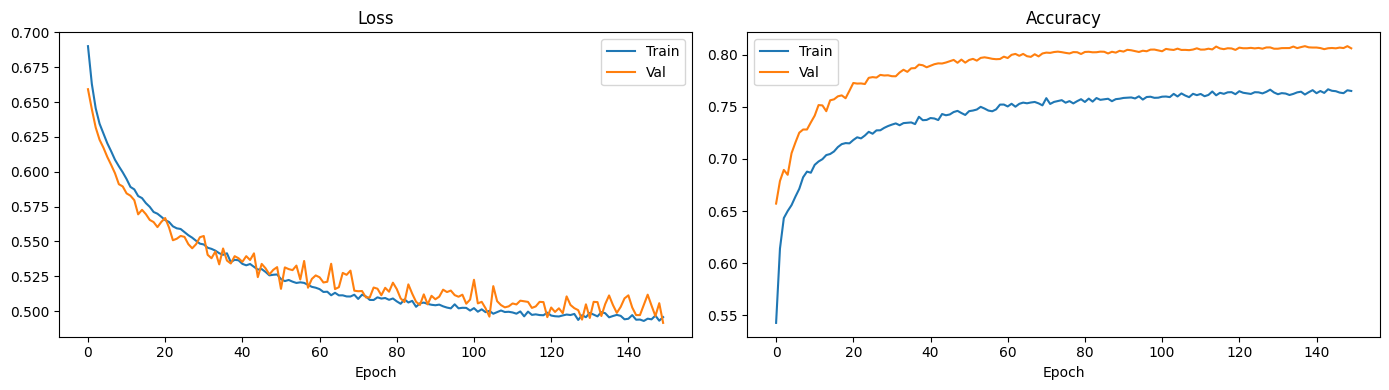

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(history['train_loss'], label='Train')
ax1.plot(history['val_loss'],   label='Val')
ax1.set_title('Loss'); ax1.set_xlabel('Epoch'); ax1.legend()
ax2.plot(history['train_acc'], label='Train')
ax2.plot(history['val_acc'],   label='Val')
ax2.set_title('Accuracy'); ax2.set_xlabel('Epoch'); ax2.legend()
plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=150)
plt.show()

## Step 9 — Evaluate on Test Set

In [9]:
ckpt = torch.load(SAVE_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt['model_state'])
model.eval()

all_preds, all_probs, all_labels = [], [], []
with torch.no_grad():
    for Xb, yb in test_loader:
        Xb     = Xb.to(DEVICE)
        logits = model(Xb)
        probs  = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
        preds  = logits.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_probs.extend(probs)
        all_labels.extend(yb.numpy())

acc = accuracy_score(all_labels, all_preds)
auc = roc_auc_score(all_labels,  all_probs)
print(f'Test Accuracy : {acc:.4f}  ({acc*100:.2f}%)')
print(f'Test AUC      : {auc:.4f}')
print()
print(classification_report(all_labels, all_preds, target_names=CLASSES))

Test Accuracy : 0.8072  (80.72%)
Test AUC      : 0.8526

              precision    recall  f1-score   support

        REST       0.75      0.62      0.68      2637
        TASK       0.83      0.90      0.86      5359

    accuracy                           0.81      7996
   macro avg       0.79      0.76      0.77      7996
weighted avg       0.80      0.81      0.80      7996



## Step 10 — Confusion Matrix

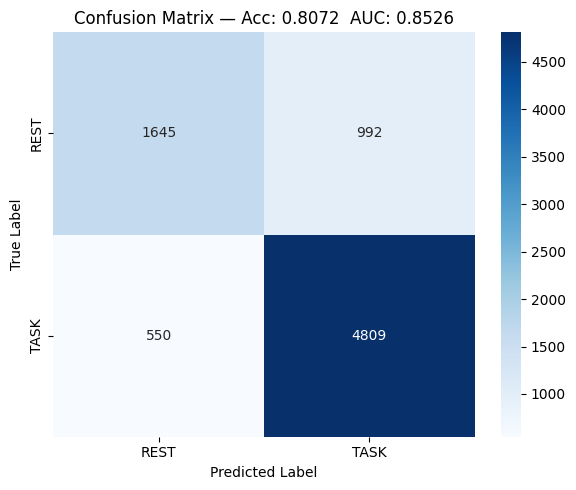

Final checkpoint saved: /kaggle/working/eegnet_best_64ch.pt


In [10]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.title(f'Confusion Matrix — Acc: {acc:.4f}  AUC: {auc:.4f}')
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix.png', dpi=150)
plt.show()

ckpt['accuracy'] = acc
ckpt['auc']      = auc
torch.save(ckpt, SAVE_PATH)
print(f'Final checkpoint saved: {SAVE_PATH}')

In [15]:
import torch, os

file = "/kaggle/working/eegnet_64ch.pt"

print(os.path.getsize(file))
ckpt = torch.load(file, map_location="cpu", weights_only=False)
print(ckpt.keys())
print(ckpt["n_channels"])

29584
dict_keys(['model_state_dict', 'n_channels', 'n_times', 'sfreq', 'class_names'])
64


In [13]:
import os

print(os.path.getsize("eegnet_64ch.pt"))

29584


In [18]:
from IPython.display import FileLink

FileLink("eegnet_64ch.pt")

/kaggle/working/eegnet_64ch.pt

In [19]:
print(X_train.shape)
print(N_CHANNELS)

(55966, 1, 64, 256)
64
